# Task 13: Direct Preference Optimization (DPO)

## Objective

Implement a simplified version of Direct Preference Optimization (DPO).

This task demonstrates:

- Preference data
- Chosen and rejected responses
- Policy model
- Reference model
- Preference scores
- DPO loss
- Model optimization

DPO is a method for aligning language models using human preference data
without requiring a separate reward model.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

torch.manual_seed(42)

print("PyTorch version:", torch.__version__)
print("Libraries imported successfully!")

PyTorch version: 2.13.0+cpu
Libraries imported successfully!


## Step 1: Create Preference Data

DPO uses preference pairs.

For each prompt, we have:

- Chosen response — preferred by the user
- Rejected response — less preferred by the user

Example:

Prompt:
"What is machine learning?"

Chosen:
"Machine learning allows computers to learn patterns from data."

Rejected:
"Machine learning is when computers magically become intelligent."

In [2]:
prompts = [
    "What is machine learning?",
    "What is RAG?",
    "What is generative AI?",
    "What is a neural network?",
    "What is prompt engineering?"
]

chosen_responses = [
    "Machine learning allows computers to learn patterns from data.",
    "RAG retrieves relevant information before generating an answer.",
    "Generative AI creates new content such as text, images and code.",
    "A neural network learns patterns using interconnected computational units.",
    "Prompt engineering involves designing effective instructions for AI models."
]

rejected_responses = [
    "Machine learning is magic.",
    "RAG is a type of database only.",
    "Generative AI only creates images.",
    "A neural network is a normal computer program.",
    "Prompt engineering means writing random questions."
]

print("Number of preference examples:", len(prompts))

Number of preference examples: 5


## Step 2: Convert Text into Simple Features

A real DPO system uses a tokenizer and a language model.

For this simplified implementation, we represent each response using
simple numerical features.

The purpose is to understand the DPO optimization process.

In [3]:
def text_features(text):

    return torch.tensor([
        len(text),
        len(text.split()),
        text.count("AI"),
        text.count("data"),
        text.count("model")
    ], dtype=torch.float32)


chosen_features = torch.stack([
    text_features(text)
    for text in chosen_responses
])

rejected_features = torch.stack([
    text_features(text)
    for text in rejected_responses
])

print("Chosen feature shape:", chosen_features.shape)
print("Rejected feature shape:", rejected_features.shape)

Chosen feature shape: torch.Size([5, 5])
Rejected feature shape: torch.Size([5, 5])


## Step 3: Create the Policy Model

The policy model represents the model that we want to optimize.

DPO increases the probability of preferred responses and decreases the
probability of rejected responses.

In [4]:
class PolicyModel(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(5, 16),
            nn.ReLU(),
            nn.Linear(16, 1)
        )

    def forward(self, x):

        return self.network(x).squeeze(-1)


policy_model = PolicyModel()

print(policy_model)

PolicyModel(
  (network): Sequential(
    (0): Linear(in_features=5, out_features=16, bias=True)
    (1): ReLU()
    (2): Linear(in_features=16, out_features=1, bias=True)
  )
)


## Step 4: Create the Reference Model

The reference model represents the original model before preference
optimization.

It remains frozen during DPO training.

The policy model is compared against this reference model.

In [5]:
reference_model = PolicyModel()

reference_model.load_state_dict(
    policy_model.state_dict()
)

for parameter in reference_model.parameters():

    parameter.requires_grad = False

print("Reference model created and frozen.")

Reference model created and frozen.


## Step 5: Calculate Response Scores

The models assign scores to responses.

Higher scores represent responses that the model prefers.

In [6]:
def get_scores(model, features):

    return model(features)


policy_chosen = get_scores(
    policy_model,
    chosen_features
)

policy_rejected = get_scores(
    policy_model,
    rejected_features
)

reference_chosen = get_scores(
    reference_model,
    chosen_features
)

reference_rejected = get_scores(
    reference_model,
    rejected_features
)

print("Policy chosen scores:")
print(policy_chosen)

print("\nPolicy rejected scores:")
print(policy_rejected)

Policy chosen scores:
tensor([3.9426, 3.9722, 4.3166, 4.6180, 4.5747], grad_fn=<SqueezeBackward1>)

Policy rejected scores:
tensor([1.7280, 2.1989, 2.1858, 3.1485, 3.1166], grad_fn=<SqueezeBackward1>)


## Step 6: Calculate DPO Loss

The simplified DPO objective encourages the policy model to assign
higher relative scores to chosen responses than rejected responses.

The basic idea is:

DPO Loss = -log(sigmoid(β × preference_difference))

where β controls the strength of the preference optimization.

In [7]:
beta = 0.1


def dpo_loss(
    policy_chosen,
    policy_rejected,
    reference_chosen,
    reference_rejected,
    beta
):

    policy_difference = (
        policy_chosen
        - policy_rejected
    )

    reference_difference = (
        reference_chosen
        - reference_rejected
    )

    preference_difference = (
        policy_difference
        - reference_difference
    )

    loss = -torch.log(
        torch.sigmoid(
            beta * preference_difference
        )
    ).mean()

    return loss

## Step 7: Initial DPO Loss

We calculate the loss before training the policy model.

In [8]:
loss = dpo_loss(
    policy_chosen,
    policy_rejected,
    reference_chosen,
    reference_rejected,
    beta
)

print(
    "Initial DPO Loss:",
    round(loss.item(), 4)
)

Initial DPO Loss: 0.6931


## Step 8: Create Optimizer

Only the policy model is updated.

The reference model remains frozen.

In [9]:
optimizer = optim.Adam(
    policy_model.parameters(),
    lr=0.01
)

print("Optimizer created.")

Optimizer created.


## Step 9: DPO Training

During training:

1. Calculate policy scores.
2. Calculate reference scores.
3. Calculate DPO loss.
4. Backpropagate the loss.
5. Update the policy model.

The objective is to make chosen responses more preferred than rejected
responses.

In [10]:
loss_history = []

epochs = 200

for epoch in range(epochs):

    policy_chosen = get_scores(
        policy_model,
        chosen_features
    )

    policy_rejected = get_scores(
        policy_model,
        rejected_features
    )

    with torch.no_grad():

        reference_chosen = get_scores(
            reference_model,
            chosen_features
        )

        reference_rejected = get_scores(
            reference_model,
            rejected_features
        )

    loss = dpo_loss(
        policy_chosen,
        policy_rejected,
        reference_chosen,
        reference_rejected,
        beta
    )

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    loss_history.append(
        loss.item()
    )

    if (epoch + 1) % 40 == 0:

        print(
            f"Epoch {epoch + 1}: "
            f"Loss = {loss.item():.4f}"
        )

Epoch 40: Loss = 0.0293
Epoch 80: Loss = 0.0058
Epoch 120: Loss = 0.0029
Epoch 160: Loss = 0.0018
Epoch 200: Loss = 0.0013


## Step 10: Training Loss

A decreasing loss indicates that the policy model is learning from the
preference pairs.

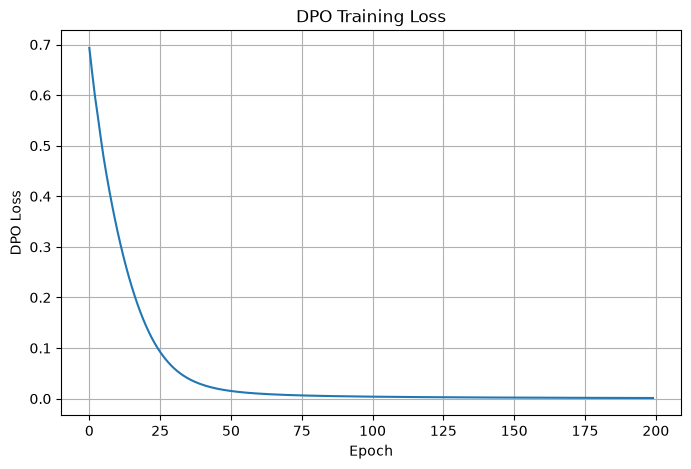

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    loss_history
)

plt.xlabel("Epoch")
plt.ylabel("DPO Loss")

plt.title(
    "DPO Training Loss"
)

plt.grid(True)

plt.show()

## Step 11: Compare Policy Preferences

We compare the average scores assigned to chosen and rejected responses
after DPO optimization.

In [12]:
with torch.no_grad():

    final_chosen_scores = get_scores(
        policy_model,
        chosen_features
    )

    final_rejected_scores = get_scores(
        policy_model,
        rejected_features
    )

print(
    "Average chosen score:",
    round(
        final_chosen_scores.mean().item(),
        4
    )
)

print(
    "Average rejected score:",
    round(
        final_rejected_scores.mean().item(),
        4
    )
)

Average chosen score: 159.9507
Average rejected score: 88.8858


## Step 12: Preference Accuracy

We check how often the policy model gives a higher score to the chosen
response than the rejected response.

In [13]:
correct_preferences = (
    final_chosen_scores
    > final_rejected_scores
)

preference_accuracy = (
    correct_preferences.float().mean()
)

print(
    "Preference Accuracy:",
    round(
        preference_accuracy.item() * 100,
        2
    ),
    "%"
)

Preference Accuracy: 100.0 %


## Step 13: Individual Preference Results

We inspect the model's preference for each example.

In [14]:
for i in range(len(prompts)):

    print("\nPrompt:")
    print(prompts[i])

    print(
        "\nChosen score:",
        round(
            final_chosen_scores[i].item(),
            4
        )
    )

    print(
        "Rejected score:",
        round(
            final_rejected_scores[i].item(),
            4
        )
    )

    if final_chosen_scores[i] > final_rejected_scores[i]:

        print("Preference: CHOSEN")

    else:

        print("Preference: REJECTED")


Prompt:
What is machine learning?

Chosen score: 144.676
Rejected score: 61.3992
Preference: CHOSEN

Prompt:
What is RAG?

Chosen score: 147.7031
Rejected score: 73.7879
Preference: CHOSEN

Prompt:
What is generative AI?

Chosen score: 155.3788
Rejected score: 82.5046
Preference: CHOSEN

Prompt:
What is a neural network?

Chosen score: 173.1621
Rejected score: 109.9819
Preference: CHOSEN

Prompt:
What is prompt engineering?

Chosen score: 178.8336
Rejected score: 116.7551
Preference: CHOSEN


## Results

The simplified DPO system demonstrates:

- Preference dataset creation
- Chosen and rejected responses
- Policy model
- Reference model
- DPO loss
- Preference optimization
- Training loss
- Preference accuracy

In [15]:
print("========== TASK 13 RESULTS ==========")

print(
    "Preference Examples:",
    len(prompts)
)

print(
    "Final DPO Loss:",
    round(
        loss_history[-1],
        4
    )
)

print(
    "Preference Accuracy:",
    round(
        preference_accuracy.item() * 100,
        2
    ),
    "%"
)

print(
    "Reference Model: Frozen"
)

print(
    "Policy Model: Optimized"
)

print("=====================================")

========== TASK 13 RESULTS ==========
Preference Examples: 5
Final DPO Loss: 0.0013
Preference Accuracy: 100.0 %
Reference Model: Frozen
Policy Model: Optimized


# Conclusion

A simplified Direct Preference Optimization system was implemented.

The system used pairs of chosen and rejected responses to optimize a
policy model.

A frozen reference model was used to compare the policy's behavior
during optimization.

The experiment demonstrates the main idea behind DPO: directly optimize
a language model using preference data without requiring a separate
reward model.

DPO is commonly used for aligning language models with human preferences.